## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
M = 1.0
w_0 = 1.0-0.0          # Natural frequency (rad/s)
w_p = 2*(w_0+0.0)      # Driving frequency (rad/s), near 2*w_0 for w_p resonance
period = 2*jnp.pi/w_0
F_p = 0.03      # Amplitude of the w_p driving
Qual = 1000.0
GAMMA = w_0/(2*Qual)
gamma = .005          # Nonlinearity coefficient (Duffing term)

k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .5             # Temperature (K)
    # Noise strength

# Simulation Parameters
t0 = 0.0  
num_periods = 5000# Start time
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
x0 = 1.0               # Initial displacement
v0 = 0.0               # Initial velocity
y0_x = jnp.array([x0, v0])


CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian(t,Q, P):
    dw = w_p/2 - w_0
    return 3*gamma/(16*w_p) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  F_p/(4*M*w_p) * (P**2 - Q**2)


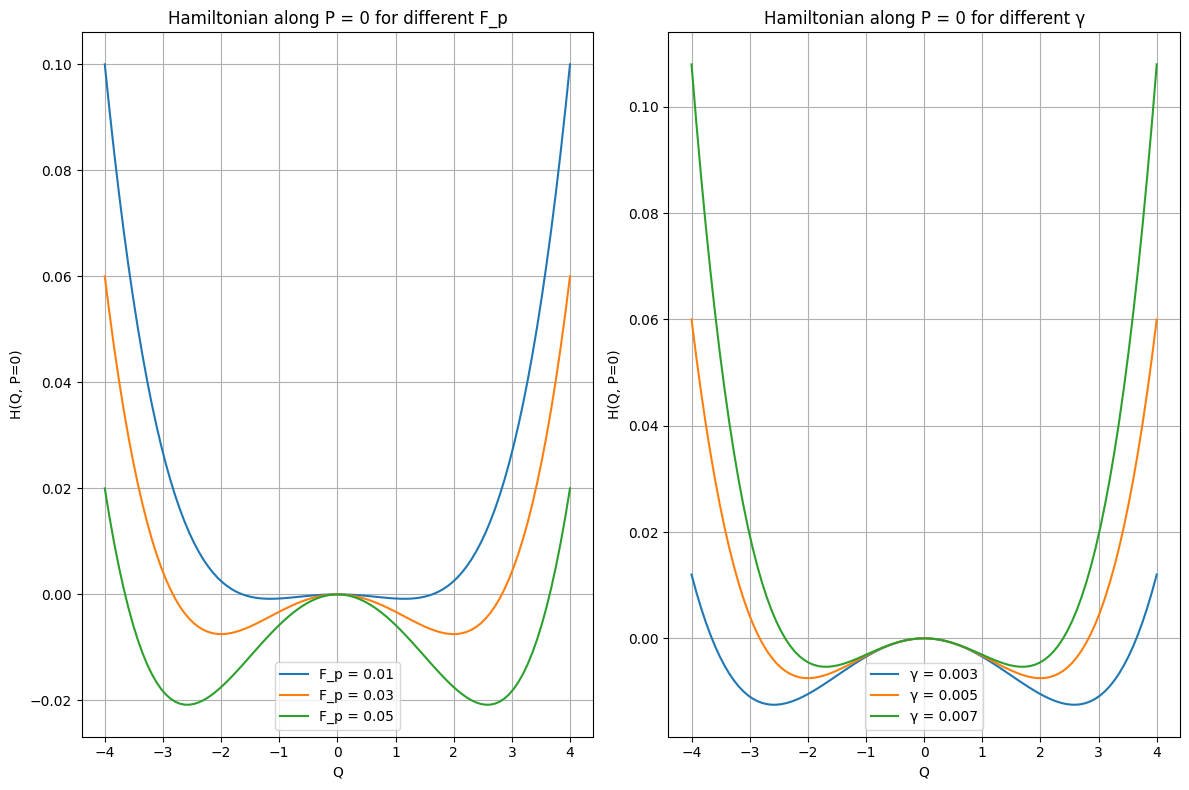

In [6]:
def Hamiltonian(t, Q, P, F_p_val, gamma_val):
    dw = w_p/2 - w_0
    return 3*gamma_val/(16*w_p) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  F_p_val/(4*M*w_p) * (P**2 - Q**2)

# Plot the Hamiltonian
Q_range = jnp.linspace(-2, 2, 100)*2
P_range = jnp.linspace(-2, 2, 100)*2
# Create meshgrid for Q and P
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Define parameter ranges
F_p_values = [0.01, 0.03, 0.05]  # Different driving amplitudes
gamma_values = [0.003, 0.005, 0.007]  # Different nonlinearity coefficients

# Create figure
plt.figure(figsize=(12, 8))

# Plot for different F_p values (keeping gamma fixed)
plt.subplot(1, 2, 1)
for F_p_val in F_p_values:
    H_P0 = jnp.array([Hamiltonian(0., q, 0., F_p_val, gamma) for q in Q_range])
    plt.plot(Q_range, H_P0, label=f'F_p = {F_p_val}')

plt.xlabel('Q')
plt.ylabel('H(Q, P=0)')
plt.title('Hamiltonian along P = 0 for different F_p')
plt.legend()
plt.grid(True)

# Plot for different gamma values (keeping F_p fixed)
plt.subplot(1, 2, 2)
for gamma_val in gamma_values:
    H_P0 = jnp.array([Hamiltonian(0., q, 0., F_p, gamma_val) for q in Q_range])
    plt.plot(Q_range, H_P0, label=f'γ = {gamma_val}')

plt.xlabel('Q')
plt.ylabel('H(Q, P=0)')
plt.title('Hamiltonian along P = 0 for different γ')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

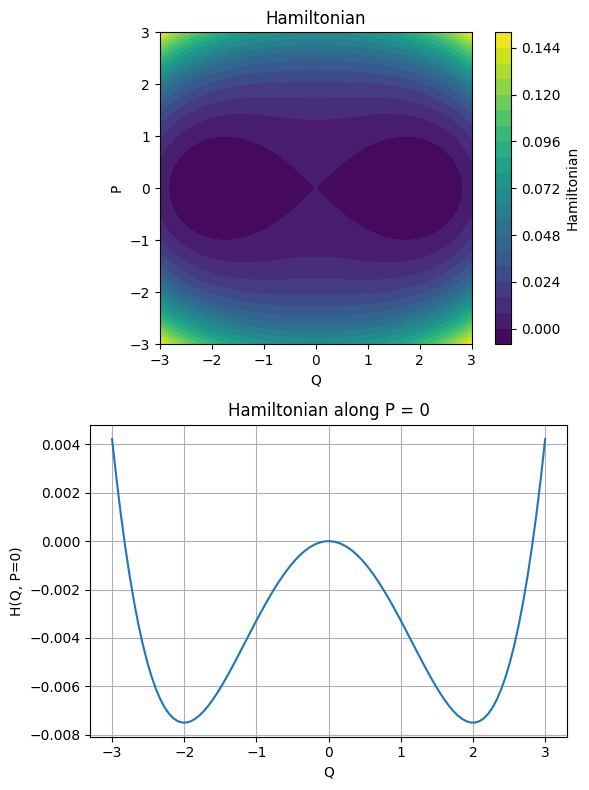

In [4]:
# Plot the Hamiltonian
Q_range = jnp.linspace(-2, 2, 100)*1.5
P_range = jnp.linspace(-2, 2, 100)*1.5
# Create meshgrid for Q and P
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Vectorize Hamiltonian over both Q and P meshgrids
H_values = jax.vmap(lambda q, p: jax.vmap(lambda qi, pi: Hamiltonian(0.,qi, pi))(q, p))(Q_mesh, P_mesh)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# Create contour plot
contour = ax1.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='Hamiltonian')
ax1.set_aspect('equal')
ax1.set_xlabel('Q')
ax1.set_ylabel('P')
ax1.set_title('Hamiltonian')

# Plot P = 0 line
H_P0 = jnp.array([Hamiltonian(0., q, 0.) for q in Q_range])
ax2.plot(Q_range, H_P0)
ax2.set_xlabel('Q')
ax2.set_ylabel('H(Q, P=0)')
ax2.set_title('Hamiltonian along P = 0')
ax2.grid(True)

plt.tight_layout()
plt.show()